# Projet Méthodes Stochastiques — notebook

Code et simulations du projet proie-prédateur avec virus. Le contexte, la démarche
et la discussion des résultats sont dans le rapport ; ce notebook se concentre sur
le code qui charge les données, estime les paramètres et régénère les figures.

## Question 1 — modèle du virus (`virus4.csv`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs

# Le fichier n'a pas d'en-tete : on nomme les colonnes a la main.
data = pd.read_csv("virus4.csv", header=None, names=["V", "P"])
V = data["V"].values
P = data["P"].values
N = len(data)
N

2000

### Estimation du pas de temps `dt`

In [2]:
# L'equation des predateurs est deterministe (dP = P(-1+V)dt) : on inverse le
# schema d'Euler pour estimer dt point par point, puis on moyenne. Le denominateur
# P(-1+V) s'annule si V ~ 1 OU si P ~ 0, on ecarte donc les points ou il est trop petit.
dP = np.diff(P)
denom = P[:-1] * (-1 + V[:-1])
masque = np.abs(denom) > 0.001

dt = np.mean(dP[masque] / denom[masque])
tau = N * dt
print(f'points ecartes : {(~masque).sum()} / {len(dP)} ({100 * (~masque).mean():.1f} %)')
print(f'dt ~ {dt:.4f}, tau ~ {tau:.1f}')

points ecartes : 84 / 1999 (4.2 %)
dt ~ 0.0150, tau ~ 30.0


### Populations observées

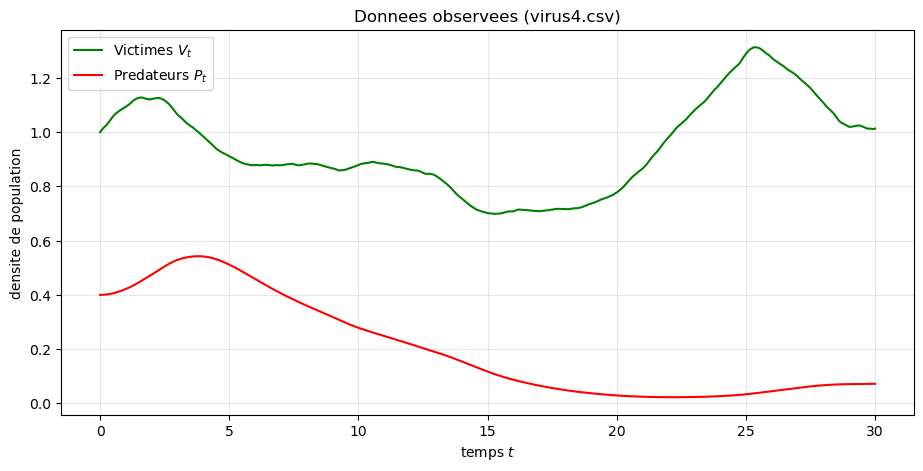

In [3]:
t = np.arange(N) * dt

plt.figure(figsize=(11, 5))
plt.plot(t, V, color="green", label="Victimes $V_t$")
plt.plot(t, P, color="red", label="Predateurs $P_t$")
plt.xlabel("temps $t$")
plt.ylabel("densite de population")
plt.title("Donnees observees (virus4.csv)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparaison avec le modèle de Lotka-Volterra classique (sans $X_t$)

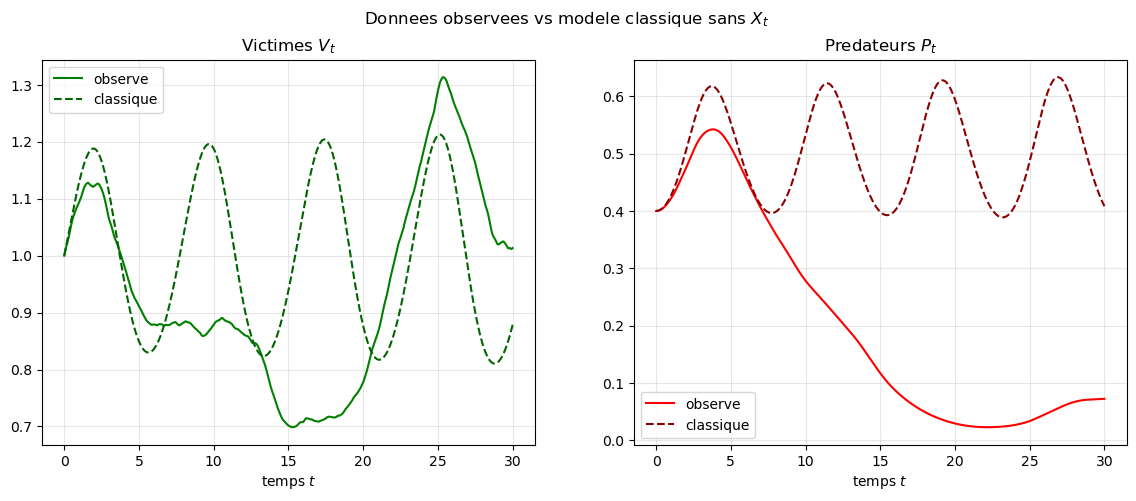

In [4]:
a, b, c, d = 2/3, 4/3, 1, 1

Vc = np.zeros(N)
Pc = np.zeros(N)
Vc[0], Pc[0] = V[0], P[0]   # memes conditions initiales que les donnees

# Euler explicite sur la meme grille de temps que les observations.
for i in range(N - 1):
    Vc[i+1] = Vc[i] + Vc[i] * (a - b * Pc[i]) * dt
    Pc[i+1] = Pc[i] + Pc[i] * (-c + d * Vc[i]) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Donnees observees vs modele classique sans $X_t$")

axes[0].plot(t, V, color="green", label="observe")
axes[0].plot(t, Vc, color="darkgreen", linestyle="--", label="classique")
axes[0].set_title("Victimes $V_t$")
axes[0].set_xlabel("temps $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, P, color="red", label="observe")
axes[1].plot(t, Pc, color="darkred", linestyle="--", label="classique")
axes[1].set_title("Predateurs $P_t$")
axes[1].set_xlabel("temps $t$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

### Reconstruction du virus $X_t$

In [5]:
# Discretisation directe de l'equation des proies :
#   V[i] - V[i-1] = V[i-1] (2/3 - 4/3 P[i-1] + X[i-1]) dt
# d'ou X[i-1] = (V[i]-V[i-1]) / (V[i-1] dt) - 2/3 + 4/3 P[i-1].
dV = np.diff(V)
X = dV / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]
tX = t[:-1]   # X[k] est attache au temps t[k]

# Artefact deterministe, sauvegarde pour que tout le monde reparte de la meme serie.
pd.DataFrame({"t": tX, "X": X}).to_csv("virus4_Xt.csv", index=False)
print(f"X reconstruit : {len(X)} points")

X reconstruit : 1999 points


### $X_t$ et ses différences $\Delta X_t$

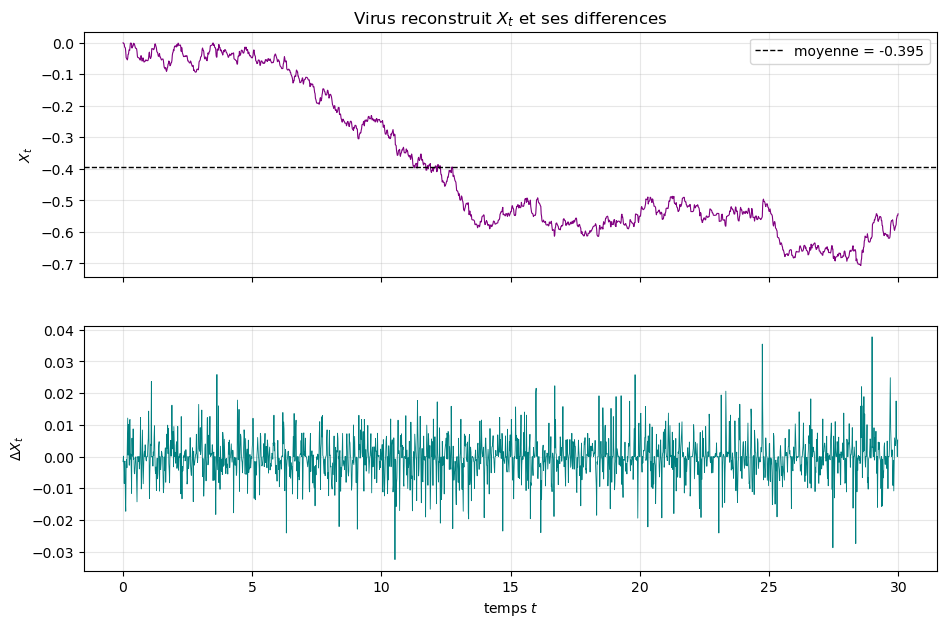

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(tX, X, color="purple", lw=0.8)
axes[0].axhline(X.mean(), color="black", ls="--", lw=1, label=f"moyenne = {X.mean():.3f}")
axes[0].set_ylabel("$X_t$")
axes[0].set_title("Virus reconstruit $X_t$ et ses differences")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(tX[:-1], np.diff(X), color="teal", lw=0.6)
axes[1].set_xlabel("temps $t$")
axes[1].set_ylabel(r"$\Delta X_t$")
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_Xt.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistiques de $X_t$ et $\Delta X_t$

Pour les différences, l'écart-type brut dépend du pas `dt` ; l'échelle qui a un sens est le
coefficient de diffusion $\sigma = \text{std}(\Delta X)/\sqrt{dt}$. On regarde aussi
l'asymétrie et la kurtosis pour juger de la normalité des différences.

In [7]:
dX = np.diff(X)
sigma = dX.std() / np.sqrt(dt)   # coefficient de diffusion, independant de dt

stats = pd.DataFrame(
    {"moyenne": [X.mean(), dX.mean()], "ecart-type": [X.std(), dX.std()]},
    index=["X_t", "dX_t"],
)
print(stats)
print(f"\nsigma = std(dX)/sqrt(dt) = {sigma:.4f}")
print(f"differences dX : asymetrie = {scs.skew(dX):.2f}, kurtosis exces = {scs.kurtosis(dX):.2f}")

       moyenne  ecart-type
X_t  -0.395169    0.227935
dX_t -0.000271    0.006377

sigma = std(dX)/sqrt(dt) = 0.0521
differences dX : asymetrie = 0.03, kurtosis exces = 3.33


### Gaussianité des différences $\Delta X_t$

On compare l'histogramme des différences à une loi normale de mêmes moyenne et écart-type.

test KS (normalite des differences) : D = 0.0881, p-value = 6.04e-14


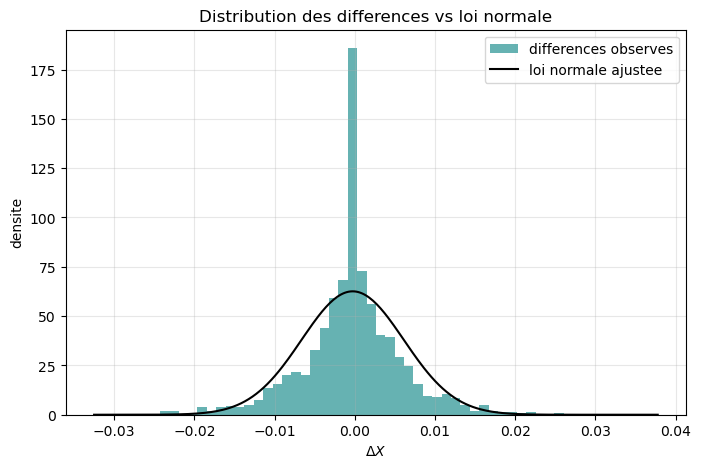

In [8]:
loi = scs.norm(dX.mean(), dX.std())   # normale calee sur moyenne et ecart-type des differences
ks = scs.kstest(dX, loi.cdf)
print(f"test KS (normalite des differences) : D = {ks.statistic:.4f}, p-value = {ks.pvalue:.2e}")
xx = np.linspace(dX.min(), dX.max(), 300)

plt.figure(figsize=(8, 5))
plt.hist(dX, bins=60, density=True, color="teal", alpha=0.6, label="differences observes")
plt.plot(xx, loi.pdf(xx), color="black", lw=1.5, label="loi normale ajustee")
plt.xlabel(r"$\Delta X$")
plt.ylabel("densite")
plt.title("Distribution des differences vs loi normale")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_dXt_hist.png", dpi=150, bbox_inches="tight")
plt.show()

### Estimation des candidats : Ornstein-Uhlenbeck et brownien avec dérive

In [9]:
# OU : regression des differences sur le niveau
#   dX_i = theta*mu*dt - theta*dt*X_i + sigma*dB_i
pente, ord0 = np.polyfit(X[:-1], dX, 1)
theta = -pente / dt
mu = ord0 / (-pente)
sigma = (dX - (pente * X[:-1] + ord0)).std() / np.sqrt(dt)
# Brownien avec derive : moments des differences
nu = dX.mean() / dt
sigma_d = dX.std() / np.sqrt(dt)
print(f'OU     : theta = {theta:.3f}, mu = {mu:.3f}, sigma = {sigma:.3f}')
print(f'derive : nu = {nu:.4f}, sigma = {sigma_d:.3f}')

OU     : theta = 0.069, mu = -0.657, sigma = 0.052
derive : nu = -0.0181, sigma = 0.052


### Test des candidats par leurs residus

derive : p-value normalite = 6.0e-14 | correlation residus consecutifs = 0.26


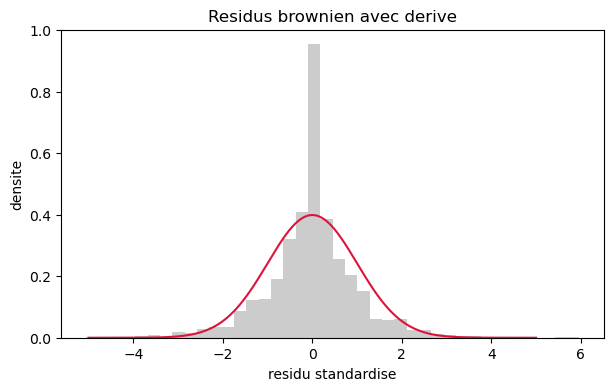

OU     : p-value normalite = 2.8e-14 | correlation residus consecutifs = 0.26


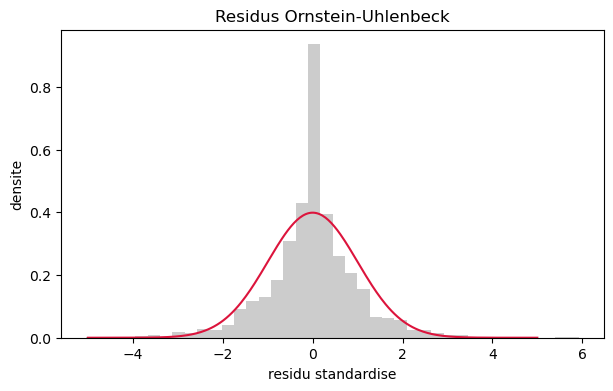

In [10]:
# Sous dX = a(X)dt + sigma dB, le residu standardise
#   eps_i = (dX_i - a(X_i)dt) / (sigma sqrt(dt)) = dB_i / sqrt(dt)
# est un increment brownien reduit, donc doit suivre N(0,1) i.i.d.
eps_ou = (dX - theta * (mu - X[:-1]) * dt) / (sigma * np.sqrt(dt))
eps_d = (dX - nu * dt) / (sigma_d * np.sqrt(dt))

for nom, eps, fname, titre in [('derive', eps_d, 'virus4_residus_derive.png', 'brownien avec derive'),
                               ('OU', eps_ou, 'virus4_residus_ou.png', 'Ornstein-Uhlenbeck')]:
    p_loi = scs.kstest(eps, 'norm').pvalue            # loi : KS a un echantillon contre N(0,1)
    corr = np.corrcoef(eps[:-1], eps[1:])[0, 1]        # independance : residus consecutifs
    print('%-7s: p-value normalite = %.1e | correlation residus consecutifs = %.2f' % (nom, p_loi, corr))
    plt.figure(figsize=(7, 4))
    plt.hist(eps, bins=40, density=True, color='0.8')
    g = np.linspace(-5, 5, 300)
    plt.plot(g, scs.norm.pdf(g), color='crimson')
    plt.xlabel('residu standardise'); plt.ylabel('densite'); plt.title('Residus ' + titre)
    plt.savefig('figures/' + fname, dpi=150, bbox_inches='tight')
    plt.show()

### Bruit coloré : OU sur les résidus du candidat Ornstein-Uhlenbeck

phi = 0.257
bruit colore : p-value normalite = 4.3e-14 | correlation innovations consecutives = 0.023


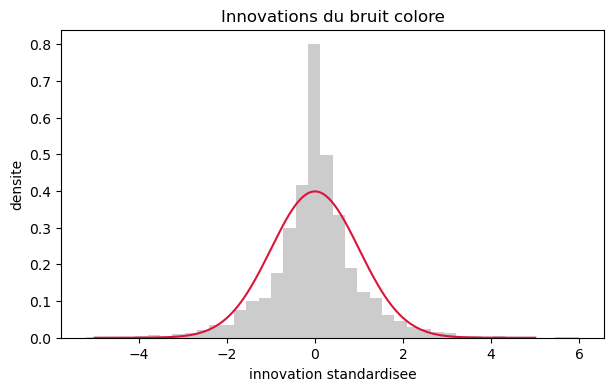

In [11]:
# Bruit colore : le bruit n'est plus blanc mais garde une memoire d'un pas au suivant,
# soit un OU sur le bruit, ce qui revient a un AR(1) sur les residus eps_i = phi eps_{i-1} + eta_i.
# On regresse eps sur son passe ; les innovations eta doivent etre N(0,1) i.i.d.
phi, _ = np.polyfit(eps_ou[:-1], eps_ou[1:], 1) #par régression linéaire : phi = pente 
eta = eps_ou[1:] - phi * eps_ou[:-1]      
eta = (eta - eta.mean()) / eta.std()      # standardisees pour comparer a N(0,1)
print(f'phi = {phi:.3f}')
p_loi = scs.kstest(eta, 'norm').pvalue  #on teste la gaussianité d'eta
corr = np.corrcoef(eta[:-1], eta[1:])[0, 1]
print('bruit colore : p-value normalite = %.1e | correlation innovations consecutives = %.3f' % (p_loi, corr))
plt.figure(figsize=(7, 4))
plt.hist(eta, bins=40, density=True, color='0.8')
g = np.linspace(-5, 5, 300)
plt.plot(g, scs.norm.pdf(g), color='crimson')
plt.xlabel('innovation standardisee'); plt.ylabel('densite'); plt.title('Innovations du bruit colore')
plt.savefig('figures/virus4_residus_colore.png', dpi=150, bbox_inches='tight')
plt.show()

nu = 2.44
innovations : p-value KS contre Student = 1.8e-02 (rappel gaussienne : 4.3e-14)


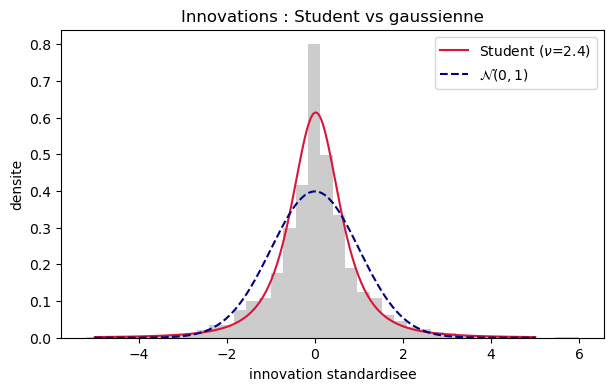

In [12]:
# La memoire etant captee par l'AR(1), il reste a corriger la loi des innovations.
# Leurs queues lourdes invitent a tester une loi de Student plutot que gaussienne.
# (NB : on sort ici du cadre brownien, ou les increments sont gaussiens par construction.)
nu, loc, sc = scs.t.fit(eta)
p_t = scs.kstest(eta, 't', args=(nu, loc, sc)).pvalue
print(f'nu = {nu:.2f}')
print('innovations : p-value KS contre Student = %.1e (rappel gaussienne : %.1e)'
      % (p_t, scs.kstest(eta, 'norm').pvalue))
plt.figure(figsize=(7, 4))
plt.hist(eta, bins=40, density=True, color='0.8')
g = np.linspace(-5, 5, 300)
plt.plot(g, scs.t.pdf(g, nu, loc, sc), color='crimson', label=f'Student ($\\nu$={nu:.1f})')
plt.plot(g, scs.norm.pdf(g), color='navy', ls='--', label=r'$\mathcal{N}(0,1)$')
plt.xlabel('innovation standardisee'); plt.ylabel('densite'); plt.title('Innovations : Student vs gaussienne')
plt.legend()
plt.savefig('figures/virus4_innovations_student.png', dpi=150, bbox_inches='tight')
plt.show()